# Signal Analysis

This notebook analyzes motion signals extracted from 2D human pose keypoints and compares different signal types for camera time synchronization.

The compared signal types are:

- Velocity signal
- Energy signal
- Selected-joint signal

## 1. Import Libraries

This section imports the required Python libraries for loading data, processing numerical results, and visualizing experiment outputs.

In [2]:
import sys
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Admin\Desktop\MyProject\P_DADN\Pose-based-time-synchronization


## 2. Load Signal Comparison Results

The signal comparison experiment compares three motion signal types using the correlation score from time offset estimation.

In [3]:
result_path = PROJECT_ROOT / "results/tables/all_sessions_signal_comparison.json"

with open(result_path, "r") as f:
    signal_results = json.load(f)

print("Number of records:", len(signal_results))
signal_results

Number of records: 9


[{'session': 'session_01',
  'signal_type': 'velocity',
  'estimated_offset_frames': 46,
  'correlation_score': 1.0},
 {'session': 'session_01',
  'signal_type': 'energy',
  'estimated_offset_frames': 46,
  'correlation_score': 1.0},
 {'session': 'session_01',
  'signal_type': 'selected_joint',
  'estimated_offset_frames': 46,
  'correlation_score': 1.0},
 {'session': 'session_02',
  'signal_type': 'velocity',
  'estimated_offset_frames': 57,
  'correlation_score': 0.42743409008447036},
 {'session': 'session_02',
  'signal_type': 'energy',
  'estimated_offset_frames': 48,
  'correlation_score': 0.46203775966319305},
 {'session': 'session_02',
  'signal_type': 'selected_joint',
  'estimated_offset_frames': 57,
  'correlation_score': 0.38459638423382614},
 {'session': 'session_03',
  'signal_type': 'velocity',
  'estimated_offset_frames': 13,
  'correlation_score': 0.29807513148324316},
 {'session': 'session_03',
  'signal_type': 'energy',
  'estimated_offset_frames': 14,
  'correlation_

## 3. Compute Average Correlation Score

For each motion signal type, the mean and standard deviation of the correlation score are computed across all sessions.

In [4]:
signal_types = sorted(set(row["signal_type"] for row in signal_results))

summary = {}

for signal in signal_types:
    scores = [
        row["correlation_score"]
        for row in signal_results
        if row["signal_type"] == signal
    ]

    summary[signal] = {
        "mean": float(np.mean(scores)),
        "std": float(np.std(scores))
    }

summary

{'energy': {'mean': 0.650143503988974, 'std': 0.24761976531247185},
 'selected_joint': {'mean': 0.598221165514151, 'std': 0.28429077060616487},
 'velocity': {'mean': 0.5751697405225712, 'std': 0.3050071005384882}}

## 4. Visualize Signal Comparison

The bar chart shows the average correlation score of each motion signal type. A higher correlation score indicates better synchronization performance.

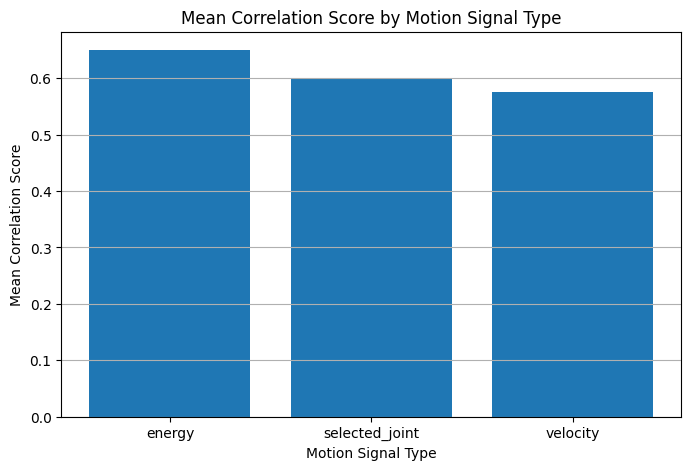

In [5]:
signals = list(summary.keys())
means = [summary[s]["mean"] for s in signals]

plt.figure(figsize=(8, 5))
plt.bar(signals, means)

plt.title("Mean Correlation Score by Motion Signal Type")
plt.xlabel("Motion Signal Type")
plt.ylabel("Mean Correlation Score")

plt.grid(axis="y")
plt.show()

## 5. Observation

From the experiment results, the energy-based motion signal achieves the highest average correlation score across the evaluated sessions.

This suggests that the energy signal provides a more stable motion representation for pose-based time synchronization compared to velocity-based and selected-joint-based signals.

## 6. Load Motion Signals

To better understand the synchronization process, we visualize the motion signals extracted from one recording session.

In this example, session_02 is selected.

In [6]:
session = "session_02"

cam1_signal = np.load(
    PROJECT_ROOT /
    f"data/processed/signals/{session}_cam1_signal.npy"
)

cam2_signal = np.load(
    PROJECT_ROOT /
    f"data/processed/signals/{session}_cam2_signal.npy"
)

print("Camera 1 signal shape:", cam1_signal.shape)
print("Camera 2 signal shape:", cam2_signal.shape)

Camera 1 signal shape: (347,)
Camera 2 signal shape: (323,)


## 7. Visualize Motion Signals

The following figure shows the normalized motion signals extracted from Camera 1 and Camera 2 before synchronization.

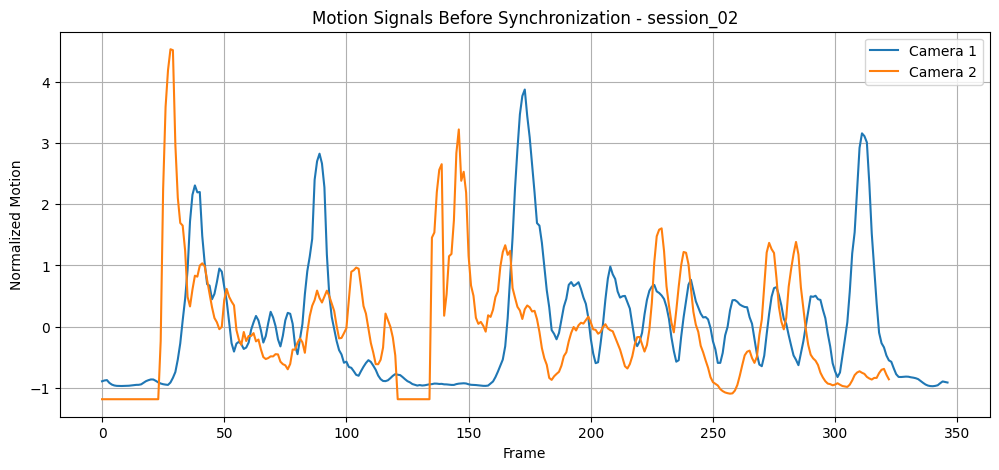

In [7]:
plt.figure(figsize=(12,5))

plt.plot(
    cam1_signal,
    label="Camera 1"
)

plt.plot(
    cam2_signal,
    label="Camera 2"
)

plt.title(
    f"Motion Signals Before Synchronization - {session}"
)

plt.xlabel("Frame")
plt.ylabel("Normalized Motion")

plt.legend()
plt.grid(True)

plt.show()

## 8. Load Synchronization Result

The estimated temporal offset is obtained using cross-correlation between the two motion signals.

In [8]:
offset_path = (
    PROJECT_ROOT /
    f"data/processed/aligned/{session}_offset.npy"
)

result = np.load(
    offset_path,
    allow_pickle=True
).item()

result

{'estimated_offset_frames': 57, 'correlation_score': 0.38459638423382614}

## 9. Discussion

The synchronization pipeline estimates temporal offsets by comparing motion signals extracted from pose sequences.

Experimental results show that:

- Different signal representations lead to different synchronization performance.
- Energy-based signals achieve the highest average correlation score.
- Correlation scores vary across sessions due to viewpoint differences and pose estimation noise.
- Motion-based synchronization can be performed without specialized hardware synchronization devices.

These observations support the feasibility of pose-based temporal synchronization for low-cost multi-camera systems.